# NLP-basierte Analyse von Verbraucherbeschwerden

In diesem Notebook werden Verbraucherbeschwerden des Consumer Financial
Protection Bureau (CFPB) analysiert. Ziel ist es, häufig diskutierte Themen
mithilfe verschiedener Verfahren des Natural Language Processing zu identifizieren.

Der Workflow umfasst:
1. Explorative Datenanalyse
2. Textvorverarbeitung
3. Bag-of-Words und TF-IDF
4. Bestimmung einer geeigneten Anzahl von Themen
5. Latent Semantic Analysis (LSA)
6. Latent Dirichlet Allocation (LDA)
7. Vergleich und Interpretation der Ergebnisse

In [42]:
## IMPORTS ##

from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

In [43]:
# Funktioniert sowohl bei Start aus dem Projektordner als auch direkt aus dem notebooks-Ordner

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "complaints_sample.csv"
)

RESULTS_PATH = PROJECT_ROOT / "results"
RESULTS_PATH.mkdir(exist_ok=True)

print(f"Projektpfad: {PROJECT_ROOT}")
print(f"Datensatz:   {DATA_PATH}")

Projektpfad: /Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp
Datensatz:   /Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/data/processed/complaints_sample.csv


In [44]:
## DATENSATZ LADEN ##

df = pd.read_csv(DATA_PATH)

print(f"Zeilen:  {df.shape[0]:,}")
print(f"Spalten: {df.shape[1]}")

df.head()

Zeilen:  10,000
Spalten: 5


,Date received,Product,Issue,Consumer complaint narrative,Complaint ID
0,2026-02-09,Checking or savings account,Managing an account,I received several wires from an individual an...,19353823
1,2026-01-08,Mortgage,Trouble during payment process,am experiencing serious issues with my mortgag...,18571024
2,2026-02-10,Mortgage,Applying for a mortgage or refinancing an exis...,I am submitting this complaint regarding Bank ...,19383905
3,2026-01-03,Debt collection,Attempts to collect debt not owed,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXXXXXX XX...,18448140
4,2026-01-27,Debt collection,Attempts to collect debt not owed,Experian. XXXX XXXXXXXX XXXX XXXXXXXX To XXXX ...,19054309


In [45]:
## VORHANDENEN VARIABLEN CHECKEN ##

df.columns.tolist()

['Date received',
 'Product',
 'Issue',
 'Consumer complaint narrative',
 'Complaint ID']

In [46]:
## DATENQUALITÄT PRÜFEN ##

df.info()
df.isna().sum()

## CHECKEN OB ES DUPLIKATE GIBT ##

print(
    "Doppelte Complaint IDs:",
    df["Complaint ID"].duplicated().sum()
)

print(
    "Doppelte Beschwerdetexte:",
    df["Consumer complaint narrative"].duplicated().sum()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 10000 non-null  object
 1   Product                       10000 non-null  object
 2   Issue                         10000 non-null  object
 3   Consumer complaint narrative  10000 non-null  object
 4   Complaint ID                  10000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
Doppelte Complaint IDs: 0
Doppelte Beschwerdetexte: 0


In [47]:
## ZEITRAUM DER DATEN PRÜFEN ##

df["Date received"] = pd.to_datetime(
    df["Date received"]
)

print(
    "Zeitraum:",
    df["Date received"].min().date(),
    "bis",
    df["Date received"].max().date()
)

Zeitraum: 2026-01-01 bis 2026-02-28


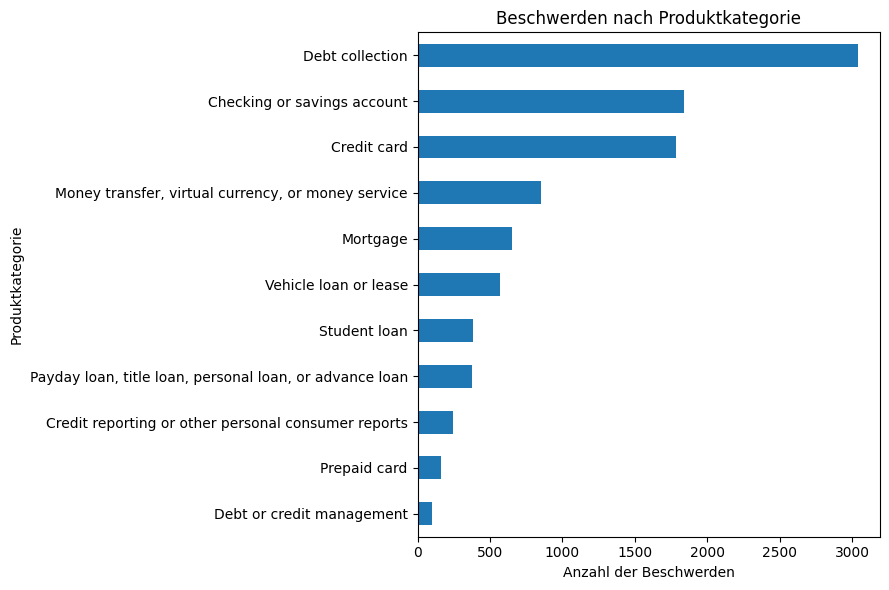

In [48]:
## NUMERISCHE VERTEILUNG DER PRODUKTKATEGORIEN ##

product_counts = df["Product"].value_counts()

product_counts

## VISUELL ##

product_counts.plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Anzahl der Beschwerden")
plt.ylabel("Produktkategorie")
plt.title("Beschwerden nach Produktkategorie")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

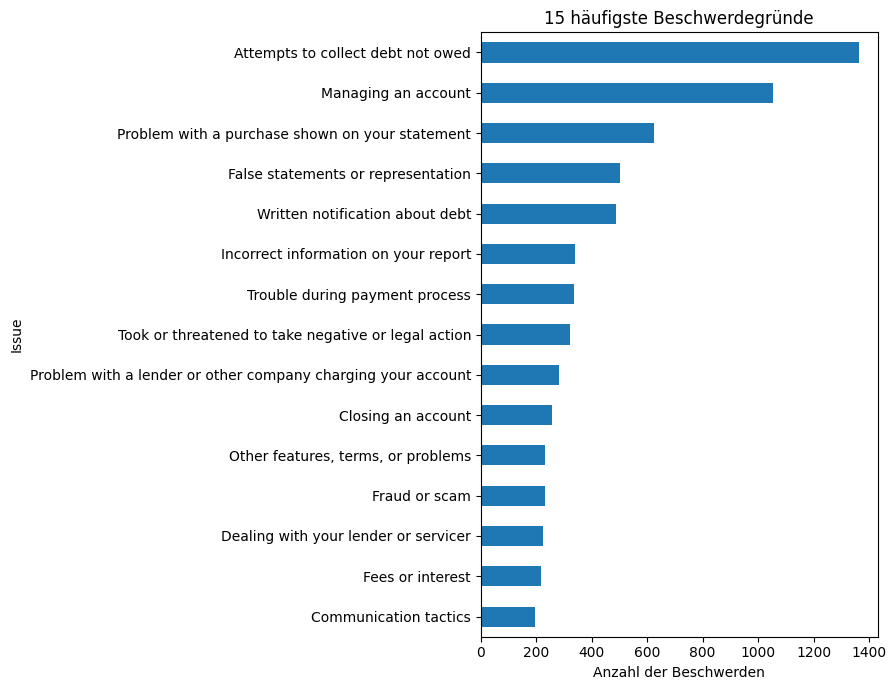

In [49]:
## HÄUFIGE ISSUES ##

issue_counts = df["Issue"].value_counts()

issue_counts.head(15)

## VISUELL ##

issue_counts.head(15).plot(
    kind="barh",
    figsize=(9, 7)
)

plt.xlabel("Anzahl der Beschwerden")
plt.ylabel("Issue")
plt.title("15 häufigste Beschwerdegründe")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

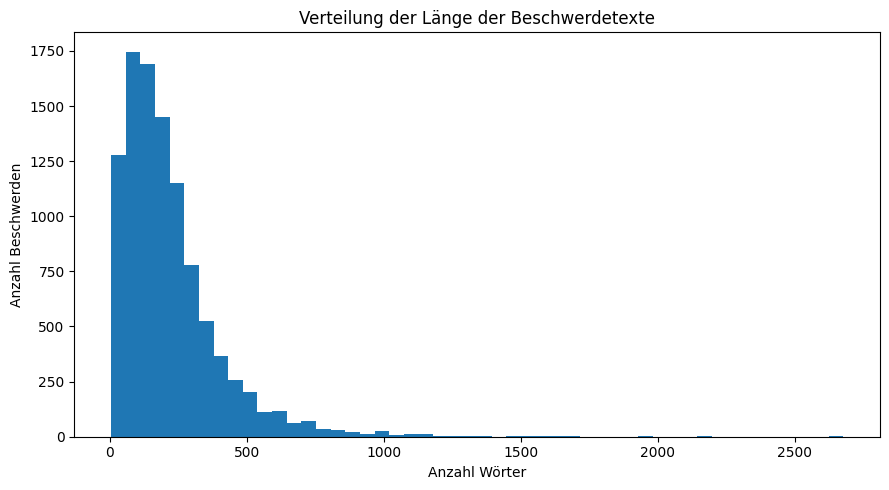

In [50]:
## LÄNGE DER BESCHWERDE TEXTE ##

df["character_count"] = (
    df["Consumer complaint narrative"]
    .str.len()
)

df["word_count"] = (
    df["Consumer complaint narrative"]
    .str.split()
    .str.len()
)

df[
    ["character_count", "word_count"]
].describe()

## VISUELL ##

df["word_count"].plot(
    kind="hist",
    bins=50,
    figsize=(9, 5)
)

plt.xlabel("Anzahl Wörter")
plt.ylabel("Anzahl Beschwerden")
plt.title("Verteilung der Länge der Beschwerdetexte")
plt.tight_layout()

plt.show()

## Textvorverarbeitung

Vor der Vektorisierung werden die unstrukturierten Beschwerdetexte bereinigt.
Dazu werden die Texte tokenisiert, in Kleinbuchstaben überführt, lemmatisiert
und von Stopwörtern, Sonderzeichen, Zahlen und Anonymisierungsmarkierungen bereinigt.

In [51]:
## spaCy LADEN ##

import spacy

nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

print(nlp.pipe_names)

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


In [52]:
## PREPROCESSING ##

CUSTOM_STOPWORDS = {
    "xx",
    "xxxx",
    "xxxxxxxx",
    "year"
    "complaint",
    "consumer",
    "company",
    "provide",
    "request",
    "review",
    "say",
    "tell",
    "not"
}


def preprocess_texts(texts):
    cleaned_texts = []

    docs = nlp.pipe(
        texts,
        batch_size=256
    )

    for doc in docs:
        tokens = []

        for token in doc:

            # Nur alphabetische Tokens
            if not token.is_alpha:
                continue

            lemma = token.lemma_.lower().strip()

            # Stopwörter entfernen
            if token.is_stop:
                continue

            # CFPB-Anonymisierungen entfernen
            if lemma in CUSTOM_STOPWORDS:
                continue

            # beliebig lange X-Platzhalter entfernen
            if re.fullmatch(r"x+", lemma):
                continue

            # Sehr kurze Tokens entfernen
            if len(lemma) <= 2:
                continue

            tokens.append(lemma)

        cleaned_texts.append(
            " ".join(tokens)
        )

    return cleaned_texts

df["clean_text"] = preprocess_texts(
    df["Consumer complaint narrative"].tolist()
)

In [53]:
## PREPROCESSING CHECK ##

df[
    [
        "Consumer complaint narrative",
        "clean_text"
    ]
].head()

example = 0

print("ORIGINAL:\n")
print(
    df.loc[
        example,
        "Consumer complaint narrative"
    ]
)

print("\n" + "=" * 80)

print("\nBEREINIGT:\n")
print(
    df.loc[
        example,
        "clean_text"
    ]
)

ORIGINAL:

I received several wires from an individual and his wife in XX/XX/year>. This was part of an investment exchange. The funds were processed accordingly and ended being sent back to him as he indicated through a third party. 
In XXXX he requested a return of the wire 45 days after they left my account and they were processed. 

Immediately All of my accounts at XXXX XXXX  were frozen. I had correspondence with one explanation to the wire department but there has been no other contact as an investigation is on going. It has been a month and I am dealing with returned checks and missed payments.


BEREINIGT:

receive wire individual wife year investment exchange fund process accordingly end send indicate party return wire day leave account process immediately account frozen correspondence explanation wire department contact investigation month deal return check miss payment


In [54]:
## ERGEBNISSKONTROLLE ##

empty_texts = (
    df["clean_text"]
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Leere Texte nach Preprocessing:",
    empty_texts
)

## ENTFERNEN LEERER TEXTE

df = df[
    df["clean_text"].str.strip() != ""
].copy()

df.reset_index(
    drop=True,
    inplace=True
)

print(
    f"Verbleibende Dokumente: {len(df):,}"
)

## WORTWAHL BEREINIGEN ##

df["clean_word_count"] = (
    df["clean_text"]
    .str.split()
    .str.len()
)

df[
    [
        "word_count",
        "clean_word_count"
    ]
].describe()

Leere Texte nach Preprocessing: 0
Verbleibende Dokumente: 10,000


,word_count,clean_word_count
count,10000.000000,10000.0000
mean,219.869900,94.3565
std,192.288034,86.9810
min,5.000000,1.0000
25%,94.000000,37.0000
50%,176.000000,73.0000
75%,283.000000,124.0000
max,2677.000000,1383.0000


In [55]:
## PREPROCESSED DATENSATZ SPEICHERN ##

PREPROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "complaints_preprocessed.csv"
)

df.to_csv(
    PREPROCESSED_PATH,
    index=False
)

print(
    f"Datei gespeichert unter:\n{PREPROCESSED_PATH}"
)

Datei gespeichert unter:
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/data/processed/complaints_preprocessed.csv


## Vektorisierung der Beschwerdetexte

Für die numerische Repräsentation der vorverarbeiteten Texte werden zwei
Verfahren miteinander verglichen: Bag-of-Words mit CountVectorizer und
Term Frequency-Inverse Document Frequency (TF-IDF).

Bag-of-Words repräsentiert Dokumente anhand der Häufigkeit einzelner Begriffe,
während TF-IDF häufig vorkommende Begriffe abhängig von ihrer Verteilung im
gesamten Korpus gewichtet.

In [56]:
## IMPORTS ##

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

## VARIABLE NEU ZUWEISEN ##

PREPROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "complaints_preprocessed.csv"
)

df = pd.read_csv(PREPROCESSED_PATH)

In [57]:
## FILTER ##

VECTORIZER_PARAMS = {
    "min_df": 5,
    "max_df": 0.95,
    "max_features": 5000
}

In [58]:
## BAG OF WORDS ##

count_vectorizer = CountVectorizer(
    **VECTORIZER_PARAMS
)

X_count = count_vectorizer.fit_transform(
    df["clean_text"]
)

count_terms = count_vectorizer.get_feature_names_out()

print("Bag-of-Words")
print("----------------")
print(f"Dokumente:  {X_count.shape[0]:,}")
print(f"Begriffe:   {X_count.shape[1]:,}")
print(f"Matrixform: {X_count.shape}")

Bag-of-Words
----------------
Dokumente:  10,000
Begriffe:   4,793
Matrixform: (10000, 4793)


In [59]:
## TF-IDF ##

tfidf_vectorizer = TfidfVectorizer(
    **VECTORIZER_PARAMS
)

X_tfidf = tfidf_vectorizer.fit_transform(
    df["clean_text"]
)

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF")
print("------")
print(f"Dokumente:  {X_tfidf.shape[0]:,}")
print(f"Begriffe:   {X_tfidf.shape[1]:,}")
print(f"Matrixform: {X_tfidf.shape}")

TF-IDF
------
Dokumente:  10,000
Begriffe:   4,793
Matrixform: (10000, 4793)


In [60]:
## SPARSITY ##

def calculate_sparsity(matrix):
    total_elements = matrix.shape[0] * matrix.shape[1]
    zero_elements = total_elements - matrix.nnz

    return zero_elements / total_elements


count_sparsity = calculate_sparsity(X_count)
tfidf_sparsity = calculate_sparsity(X_tfidf)

print(
    f"Bag-of-Words Sparsity: "
    f"{count_sparsity:.2%}"
)

print(
    f"TF-IDF Sparsity: "
    f"{tfidf_sparsity:.2%}"
)

Bag-of-Words Sparsity: 98.78%
TF-IDF Sparsity: 98.78%


In [61]:
## HÄUFIGSTEN BEGRIFFE ##

import pandas as pd

count_frequencies = X_count.sum(axis=0).A1

count_frequency_df = (
    pd.DataFrame({
        "term": count_terms,
        "frequency": count_frequencies
    })
    .sort_values(
        "frequency",
        ascending=False
    )
)

count_frequency_df.head(20)

## HÄUFIGSTEN BEGRIFFE BAG-OF-WORDS ##

count_frequencies = X_count.sum(axis=0).A1

count_frequency_df = (
    pd.DataFrame({
        "term": count_terms,
        "frequency": count_frequencies
    })
    .sort_values(
        "frequency",
        ascending=False
    )
    .reset_index(drop=True)
)

count_frequency_df.head(20)

,term,frequency
0,account,24595
1,credit,14578
2,report,10525
3,payment,10278
4,debt,9566
5,dispute,9093
6,bank,7092
7,receive,6520
8,information,6360
9,charge,6186


In [62]:
## HÄUFIGSTEN BEGRIFFE TF-IDF ##

tfidf_scores = X_tfidf.sum(axis=0).A1

tfidf_score_df = (
    pd.DataFrame({
        "term": tfidf_terms,
        "tfidf_score": tfidf_scores
    })
    .sort_values(
        "tfidf_score",
        ascending=False
    )
)

tfidf_score_df.head(20)

,term,tfidf_score
41,account,707.075401
969,credit,525.656223
1038,debt,485.035430
3553,report,478.551862
3011,payment,376.134659
1255,dispute,329.404590
390,bank,309.299689
556,card,288.119476
621,charge,274.245832
718,collection,271.125188


In [63]:
## ANZAHL AN THEMEN BESTIMMEN ##

## IMPORTS ##

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation

In [64]:
## TEXTE VORBEREITEN ##

tokenized_texts = [
    text.split()
    for text in df["clean_text"]
]

dictionary = Dictionary(tokenized_texts)

In [65]:
## HILFSFUNKTION ##

def get_topic_words(model, feature_names, n_words=10):
    topics = []

    for topic_weights in model.components_:
        top_indices = topic_weights.argsort()[-n_words:][::-1]

        topic = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append(topic)

    return topics


def calculate_coherence(
    model,
    feature_names,
    tokenized_texts,
    dictionary,
    n_words=10
):
    topics = get_topic_words(
        model,
        feature_names,
        n_words=n_words
    )

    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()

In [66]:
## TEST RANGE FÜR ANZAHL DER TOPICS ##

TOPIC_RANGE = range(2, 16)

## LSA ##

lsa_results = []

for n_topics in TOPIC_RANGE:

    lsa_model = TruncatedSVD(
        n_components=n_topics,
        random_state=42
    )

    lsa_model.fit(X_tfidf)

    coherence = calculate_coherence(
        model=lsa_model,
        feature_names=tfidf_terms,
        tokenized_texts=tokenized_texts,
        dictionary=dictionary
    )

    explained_variance = (
        lsa_model.explained_variance_ratio_.sum()
    )

    lsa_results.append({
        "topics": n_topics,
        "coherence": coherence,
        "explained_variance": explained_variance
    })

lsa_results_df = pd.DataFrame(lsa_results)

lsa_results_df


/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/p

,topics,coherence,explained_variance
0,2,0.636543,0.035749
1,3,0.560332,0.051900
2,4,0.559633,0.063566
3,5,0.533954,0.074857
4,6,0.515546,0.084246
5,7,0.512611,0.092320
6,8,0.495088,0.099292
7,9,0.489445,0.106181
8,10,0.487714,0.112611
9,11,0.476449,0.118409


In [67]:
## ZUR ÜBERSICHT ##

lsa_results_df.sort_values(
    "coherence",
    ascending=False
).head()

,topics,coherence,explained_variance
0,2,0.636543,0.035749
1,3,0.560332,0.051900
2,4,0.559633,0.063566
3,5,0.533954,0.074857
4,6,0.515546,0.084246


In [68]:
## LDA ##

lda_results = []

for n_topics in TOPIC_RANGE:

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="online",
        max_iter=10,
        n_jobs=-1
    )

    lda_model.fit(X_count)

    coherence = calculate_coherence(
        model=lda_model,
        feature_names=count_terms,
        tokenized_texts=tokenized_texts,
        dictionary=dictionary
    )

    perplexity = lda_model.perplexity(X_count)

    lda_results.append({
        "topics": n_topics,
        "coherence": coherence,
        "perplexity": perplexity
    })

lda_results_df = pd.DataFrame(lda_results)

lda_results_df

/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-

,topics,coherence,perplexity
0,2,0.563762,821.759174
1,3,0.507748,771.345579
2,4,0.564450,754.663425
3,5,0.518700,738.059713
4,6,0.539860,725.483412
5,7,0.584352,708.170354
6,8,0.569613,701.454393
7,9,0.555796,705.045077
8,10,0.544758,712.010434
9,11,0.542247,705.969310


In [69]:
## ZUR ÜBERSICHT ##

lda_results_df.sort_values(
    "coherence",
    ascending=False
).head()

,topics,coherence,perplexity
13,15,0.597263,699.685480
5,7,0.584352,708.170354
6,8,0.569613,701.454393
2,4,0.564450,754.663425
0,2,0.563762,821.759174


| Verfahren | Kandidaten | Warum? |
| --- | --- | --- |
| LSA | 5, eventuell 4 und 6 | guter Kompromiss aus Coherence und Informationsgehalt |
| LDA | 11, eventuell 13 | höchste Coherence; 13 bessere Perplexity |


In [78]:
## TOPIC WÖRTER ##

def display_topics(model, feature_names, n_words=10):
    topics = []

    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[-n_words:][::-1]

        top_words = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append({
            "topic": topic_idx + 1,
            "words": ", ".join(top_words)
        })

    return pd.DataFrame(topics)

In [80]:
## TABELLENBREITE ERWEITERN ##

pd.set_option("display.max_colwidth", 200)

## LSA ##

lsa_5 = TruncatedSVD(
    n_components=5,
    random_state=42
)

lsa_5.fit(X_tfidf)

display_topics(
    lsa_5,
    tfidf_terms,
    n_words=10
)

for n_topics in [4, 5, 6]:

    model = TruncatedSVD(
        n_components=n_topics,
        random_state=42
    )

    model.fit(X_tfidf)

    print(f"\nLSA mit {n_topics} Topics")
    display(display_topics(
        model,
        tfidf_terms,
        n_words=10
    ))


LSA mit 4 Topics


/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


,topic,words
0,1,"account, debt, credit, report, dispute, collection, payment, reporting, information, bank"
1,2,"debt, report, collection, validation, reporting, falsely, credit, fair, act, fdcpa"
2,3,"falsely, report, credit, account, research, code, investigation, disclosure, file, number"
3,4,"payment, loan, late, pay, interest, balance, mortgage, fee, month, reporting"



LSA mit 5 Topics


/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


,topic,words
0,1,"account, debt, credit, report, dispute, collection, payment, reporting, information, bank"
1,2,"debt, report, collection, validation, reporting, falsely, credit, fair, act, fdcpa"
2,3,"falsely, report, credit, account, research, code, investigation, disclosure, number, file"
3,4,"payment, loan, late, pay, interest, balance, mortgage, fee, month, reporting"
4,5,"debt, falsely, call, pay, money, send, collector, number, research, ask"



LSA mit 6 Topics


/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


,topic,words
0,1,"account, debt, credit, report, dispute, collection, payment, reporting, information, bank"
1,2,"debt, report, collection, validation, reporting, falsely, credit, fair, act, fdcpa"
2,3,"falsely, report, credit, account, research, code, investigation, disclosure, file, number"
3,4,"payment, loan, late, pay, interest, balance, mortgage, fee, month, reporting"
4,5,"debt, falsely, call, pay, money, send, collector, number, research, ask"
5,6,"account, open, check, money, deposit, close, reporting, fund, identity, information"


In [81]:
## LDA ##

for n_topics in [7, 15]:

    model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="online",
        max_iter=10,
        n_jobs=-1
    )

    model.fit(X_count)

    print(f"\nLDA mit {n_topics} Topics")

    display(
        display_topics(
            model,
            count_terms,
            n_words=10
        )
    )


LDA mit 7 Topics


,topic,words
0,1,"account, bank, transaction, fund, fraud, unauthorized, chase, transfer, access, card"
1,2,"law, act, contract, violation, legal, notice, demand, sign, agreement, federal"
2,3,"loan, payment, mortgage, interest, vehicle, financial, pay, servicing, year, time"
3,4,"credit, account, report, reporting, information, dispute, inaccurate, balance, fair, act"
4,5,"debt, collection, account, validation, original, dispute, collect, report, credit, fdcpa"
5,6,"charge, dispute, fee, payment, credit, merchant, refund, service, issue, card"
6,7,"account, call, pay, receive, card, send, time, money, day, bank"



LDA mit 15 Topics


,topic,words
0,1,"interest, payment, fee, balance, financial, loan, insurance, pay, cause, hardship"
1,2,"debt, proof, original, account, validation, documentation, collection, agreement, reporting, dispute"
2,3,"loan, mortgage, property, servicer, document, escrow, servicing, home, foreclosure, application"
3,4,"payment, credit, late, balance, account, vehicle, date, history, delinquency, loan"
4,5,"debt, collection, account, validation, write, cease, notice, fdcpa, letter, collect"
5,6,"issue, cash, receive, contact, fund, confirm, app, refund, attempt, process"
6,7,"account, bank, fund, deposit, close, check, wells, fargo, capital, closure"
7,8,"call, phone, email, number, send, ask, receive, account, information, time"
8,9,"pay, payment, money, day, account, bank, time, send, check, year"
9,10,"report, credit, account, reporting, information, dispute, inaccurate, fair, fcra, act"


## Finale Topic-Modelle

Auf Grundlage der quantitativen Evaluierung und der qualitativen
Interpretierbarkeit werden 4 Komponenten für LSA und 15
Topics für LDA ausgewählt.

Die Wahl berücksichtigt neben der Topic Coherence auch die
thematische Abgrenzbarkeit und die Vermeidung redundanter Topics.

In [83]:
from sklearn.decomposition import (
    TruncatedSVD,
    LatentDirichletAllocation
)

FINAL_LSA_TOPICS = 4
FINAL_LDA_TOPICS = 15

# Finales LSA-Modell
lsa_final = TruncatedSVD(
    n_components=FINAL_LSA_TOPICS,
    random_state=42
)

X_lsa = lsa_final.fit_transform(X_tfidf)

# Finales LDA-Modell
lda_final = LatentDirichletAllocation(
    n_components=FINAL_LDA_TOPICS,
    random_state=42,
    learning_method="online",
    max_iter=10,
    n_jobs=-1
)

X_lda = lda_final.fit_transform(X_count)

print("LSA:", X_lsa.shape)
print("LDA:", X_lda.shape)

/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/pascal/Library/Mobile Documents/com~apple~CloudDocs/IU International University/5. Semester/Projekt - Data Analysis/git-clone/project-data-analysis-nlp/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


LSA: (10000, 4)
LDA: (10000, 15)


In [ ]:
## AUSGABE DER FINALEN TOPICS ##

lsa_topics_df = display_topics(
    lsa_final,
    tfidf_terms,
    n_words=15
)

lda_topics_df = display_topics(
    lda_final,
    count_terms,
    n_words=15
)

display(lsa_topics_df)
display(lda_topics_df)

,topic,words
0,1,"account, debt, credit, report, dispute, collection, payment, reporting, information, bank, charge, validation, card, balance, receive"
1,2,"debt, report, collection, validation, reporting, falsely, credit, fair, act, fdcpa, agency, collect, collector, original, creditor"
2,3,"falsely, report, credit, account, research, code, investigation, disclosure, file, number, violation, collector, right, open, fair"
3,4,"payment, loan, late, pay, interest, balance, mortgage, fee, month, reporting, credit, inaccurate, mohela, vehicle, apply"


,topic,words
0,1,"interest, payment, fee, balance, financial, loan, insurance, pay, cause, hardship, time, practice, result, account, approximately"
1,2,"debt, proof, original, account, validation, documentation, collection, agreement, reporting, dispute, contract, credit, verification, include, sign"
2,3,"loan, mortgage, property, servicer, document, escrow, servicing, home, foreclosure, application, title, borrower, loss, modification, year"
3,4,"payment, credit, late, balance, account, vehicle, date, history, delinquency, loan, notice, reporting, reflect, charge, despite"
4,5,"debt, collection, account, validation, write, cease, notice, fdcpa, letter, collect, communication, send, receive, activity, dispute"
5,6,"issue, cash, receive, contact, fund, confirm, app, refund, attempt, process, resolution, representative, state, submit, despite"
6,7,"account, bank, fund, deposit, close, check, wells, fargo, capital, closure, access, open, branch, customer, checking"
7,8,"call, phone, email, number, send, ask, receive, account, information, time, contact, know, message, state, try"
8,9,"pay, payment, money, day, account, bank, time, send, check, year, month, receive, call, ask, need"
9,10,"report, credit, account, reporting, information, dispute, inaccurate, fair, fcra, act, investigation, file, agency, delete, violation"


In [ ]:
## TOPIC VERTEILUNG ##

import numpy as np

df["lda_topic"] = np.argmax(X_lda, axis=1) + 1

topic_distribution = (
    df["lda_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("Topic")
    .reset_index(name="Beschwerden")
)

topic_distribution["Anteil (%)"] = (
    topic_distribution["Beschwerden"]
    / len(df)
    * 100
).round(2)

topic_distribution

,Topic,Beschwerden,Anteil (%)
0,1,695,6.95
1,2,427,4.27
2,3,166,1.66
3,4,570,5.70
4,5,860,8.60
5,6,693,6.93
6,7,419,4.19
7,8,910,9.10
8,9,1772,17.72
9,10,1167,11.67


# Interpretation und Validierung der Topics

In [88]:
import numpy as np

df["lda_topic"] = np.argmax(X_lda, axis=1) + 1
df["lda_probability"] = X_lda.max(axis=1)

df[
    ["lda_topic", "lda_probability"]
].head()

,lda_topic,lda_probability
0,9,0.430814
1,6,0.341651
2,11,0.492644
3,13,0.408968
4,10,0.529481


In [89]:
df["lda_probability"].describe()

count    10000.000000
mean         0.468030
std          0.161497
min          0.144051
25%          0.349135
50%          0.437116
75%          0.555441
max          0.998894
Name: lda_probability, dtype: float64

In [ ]:
## TOP TOPICS ##

top_products = (
    df.groupby("lda_topic")["Product"]
    .value_counts()
    .groupby(level=0)
    .head(3)
    .rename("count")
    .reset_index()
)

top_products

,lda_topic,Product,count
0,1,Credit card,187
1,1,Mortgage,122
2,1,"Payday loan, title loan, personal loan, or advance loan",78
3,2,Debt collection,410
4,2,Credit card,6
5,2,Credit reporting or other personal consumer reports,3
6,3,Mortgage,114
7,3,Debt collection,17
8,3,Student loan,10
9,4,Vehicle loan or lease,196


In [91]:
## TOP ISSUES ##

top_issues = (
    df.groupby("lda_topic")["Issue"]
    .value_counts()
    .groupby(level=0)
    .head(3)
    .rename("count")
    .reset_index()
)

top_issues

,lda_topic,Issue,count
0,1,Fees or interest,77
1,1,Trouble during payment process,68
2,1,Charged fees or interest you didn't expect,37
3,2,Attempts to collect debt not owed,194
4,2,False statements or representation,102
5,2,Written notification about debt,77
6,3,Struggling to pay mortgage,46
7,3,Trouble during payment process,35
8,3,Applying for a mortgage or refinancing an existing mortgage,17
9,4,Incorrect information on your report,103


In [ ]:
## BESCHWERDEN PRO TOPIC ##

representative_complaints = (
    df.sort_values(
        ["lda_topic", "lda_probability"],
        ascending=[True, False]
    )
    .groupby("lda_topic")
    .head(3)
)

representative_complaints[
    [
        "lda_topic",
        "lda_probability",
        "Product",
        "Issue",
        "Consumer complaint narrative"
    ]
]

,lda_topic,lda_probability,Product,Issue,Consumer complaint narrative
7234,1,0.933333,Checking or savings account,Problem caused by your funds being low,I was not advised of the higher interest rates available on my account at any time and was only given the lower interest rate when it shouldve been higher and I was not notified of that
6892,1,0.902196,"Payday loan, title loan, personal loan, or advance loan",Problem when making payments,"In XX/XX/XXXX, I obtained a {$2600.00} installment loan requiring weekly payments of {$110.00} at an XXXX of approximately 160 %. \n\nSince XX/XX/XXXX, I have made multiple weekly payments as agre..."
1805,1,0.879534,Credit card,Fees or interest,"I financed a XXXX purchase through XXXX XXXX XXXX using a Comenity Bank promotional credit account that was explicitly marketed as a no-interest, deferred-interest plan for a fixed promotional pe..."
569,2,0.984699,Debt collection,Attempts to collect debt not owed,"SECURITYCRED XXXX XXXX XXXX XXXX, XXXX XXXX, Validation of Debt Request - SECURITY CREDIT SERVIC - XXXX * XXXX I am disputing this account as inaccurate and request full validation, including the ..."
2755,2,0.984444,Debt collection,Attempts to collect debt not owed,"Validation of Debt Request - CREDENCE RESOURCE XXXX - XXXX XXXX XXXX XXXX XXXXXXXX I am disputing this account as inaccurate and request full validation, including the original signed agreement an..."
2233,2,0.984181,Debt collection,Attempts to collect debt not owed,"Validation of Debt Request - SPRINGOAKCAP - XXXXXXXX XXXX XXXX XXXX XXXXXXXX I am disputing this account as inaccurate and request full validation, including the original signed agreement and comp..."
3452,3,0.671361,Mortgage,Problem with a company's investigation into an existing problem,"I sold a property on XX/XX/year>, paid of the HELOC through escrow, signed a form to close the loan after payoff ( in escrow ), and the loan was never closed. I still have a loan in my name with a..."
63,3,0.620365,Mortgage,Trouble during payment process,Loan was sold from XXXX XXXX to mr cooper/XXXX mortgage in XX/XX/year>. Ive complied and made all my payments on time. I was a repayment plan that was to transfer over. I received a letter XXXX we...
1704,3,0.580509,Mortgage,Closing on a mortgage,HELOC satisfied in 2022 Property sold and lien released
41,4,0.922222,Credit card,Problem with a company's investigation into an existing problem,Contradictory paid status severe inconsistencies in financial data and uncorrected derogatory history on closed account.


In [96]:
## TOPIC NAMEN ##

TOPIC_LABELS = {
    1: "Gebühren, Zinsen und Zahlungsprobleme",
    2: "Forderungsnachweis und Schuldenvalidierung",
    3: "Hypotheken und Immobilienfinanzierung",
    4: "Kredit-/Leasingzahlungen und Zahlungsrückstände",
    5: "Inkasso und Forderungseintreibung",
    6: "Zahlungsabwicklung und Finanzdienstleistungen",
    7: "Bankkonten und Kontoverwaltung",
    8: "Kommunikation und Kontaktaufnahme",
    9: "Allgemeine Zahlungs- und Kontoprobleme",
    10: "Kreditberichte und fehlerhafte Meldungen",
    11: "Transaktions- und Händlerstreitigkeiten",
    12: "Kreditkartenbelastungen und Käufe",
    13: "Rechtliche Verstöße bei Forderungen",
    14: "Werbeangebote und Kontoeröffnung",
    15: "Betrug und Identitätsmissbrauch"
}

df["lda_topic_label"] = df["lda_topic"].map(TOPIC_LABELS)

lsa_topics_df.to_csv(
    RESULTS_PATH / "lsa_topics.csv",
    index=False
)

lda_topics_df.to_csv(
    RESULTS_PATH / "lda_topics.csv",
    index=False
)

topic_distribution = (
    df["lda_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("Topic")
    .reset_index(name="Beschwerden")
)

topic_distribution["Anteil (%)"] = (
    topic_distribution["Beschwerden"]
    / len(df)
    * 100
).round(2)

topic_distribution.to_csv(
    RESULTS_PATH / "lda_topic_distribution.csv",
    index=False
)

top_products.to_csv(
    RESULTS_PATH / "lda_top_products.csv",
    index=False
)

top_issues.to_csv(
    RESULTS_PATH / "lda_top_issues.csv",
    index=False
)

In [99]:
## ERGEBNISTABELLEN ##

topic_summary = (
    df["lda_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("Topic")
    .reset_index(name="Beschwerden")
)

topic_summary["Anteil (%)"] = (
    topic_summary["Beschwerden"]
    / len(df)
    * 100
).round(2)

topic_summary["Bezeichnung"] = (
    topic_summary["Topic"]
    .map(TOPIC_LABELS)
)

topic_summary = topic_summary[
    ["Topic", "Bezeichnung", "Beschwerden", "Anteil (%)"]
]

display(topic_summary)

## ERGEBNIS SPEICHERN ##

topic_summary.to_csv(
    RESULTS_PATH / "lda_topic_summary.csv",
    index=False
)

,Topic,Bezeichnung,Beschwerden,Anteil (%)
0,1,"Gebühren, Zinsen und Zahlungsprobleme",695,6.95
1,2,Forderungsnachweis und Schuldenvalidierung,427,4.27
2,3,Hypotheken und Immobilienfinanzierung,166,1.66
3,4,Kredit-/Leasingzahlungen und Zahlungsrückstände,570,5.70
4,5,Inkasso und Forderungseintreibung,860,8.60
5,6,Zahlungsabwicklung und Finanzdienstleistungen,693,6.93
6,7,Bankkonten und Kontoverwaltung,419,4.19
7,8,Kommunikation und Kontaktaufnahme,910,9.10
8,9,Allgemeine Zahlungs- und Kontoprobleme,1772,17.72
9,10,Kreditberichte und fehlerhafte Meldungen,1167,11.67


## Interpretation der Ergebnisse

Die LSA mit vier Komponenten identifiziert überwiegend breite Themenbereiche
rund um Kreditberichte, Schuldeneintreibung sowie Kredite und Zahlungen.
Die LDA liefert mit 15 Topics eine deutlich feinere thematische Struktur.

Besonders klar abgrenzbar sind Themen zu Hypotheken, Bankkonten,
Kreditberichten, Kreditkartenbelastungen und Transaktionsstreitigkeiten.
Die nachträgliche Gegenüberstellung mit den CFPB-Variablen Product und Issue
bestätigt für viele Topics eine plausible inhaltliche Zuordnung.

Einige Topics weisen Überschneidungen auf, insbesondere im Bereich
Schuldeneintreibung sowie allgemeiner Konto- und Zahlungsprobleme.
Dies verdeutlicht, dass Beschwerden häufig mehrere inhaltliche Aspekte
gleichzeitig enthalten.

| Kriterium | LSA | LDA |
|---|---|---|
| Vektorisierung | TF-IDF | Bag-of-Words |
| Finale Themenanzahl | 4 | 15 |
| Modellprinzip | Dimensionsreduktion | Probabilistisches Topic-Modell |
| Ergebnis | Breite Themenstrukturen | Feinere thematische Differenzierung |
| Stärke | Kompakte Übersicht | Detaillierte Themenextraktion |
| Einschränkung | Stärkere Überschneidungen | Teilweise kleine bzw. ähnliche Topics |